In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Simulated RNA-seq data (genes × samples)
np.random.seed(42)

data = pd.DataFrame(
    np.random.rand(100, 6),
    index=[f'Gene_{i}' for i in range(100)],
    columns=['Control_1', 'Control_2', 'Control_3',
                         'Stress_1', 'Stress_2', 'Stress_3']
                         )

data.head()

,Control_1,Control_2,Control_3,Stress_1,Stress_2,Stress_3
Gene_0,0.374540,0.950714,0.731994,0.598658,0.156019,0.155995
Gene_1,0.058084,0.866176,0.601115,0.708073,0.020584,0.969910
Gene_2,0.832443,0.212339,0.181825,0.183405,0.304242,0.524756
Gene_3,0.431945,0.291229,0.611853,0.139494,0.292145,0.366362
Gene_4,0.456070,0.785176,0.199674,0.514234,0.592415,0.046450


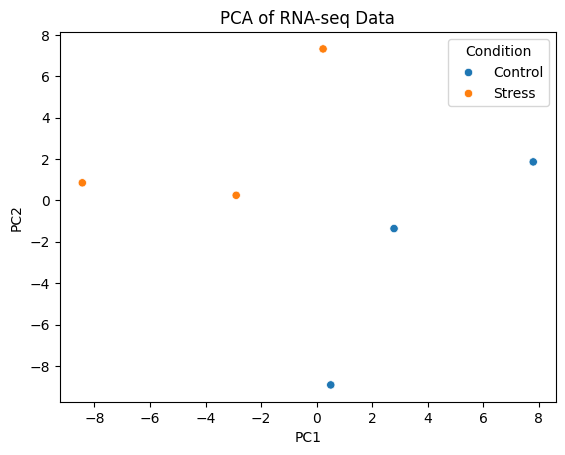

In [ ]:
# Transpose data (samples as rows)
data_t = data.T

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_t)

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create DataFrame
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Condition'] = ['Control']*3 + ['Stress']*3

# Plot PCA
plt.figure()
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Condition')
plt.title('PCA of RNA-seq Data')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

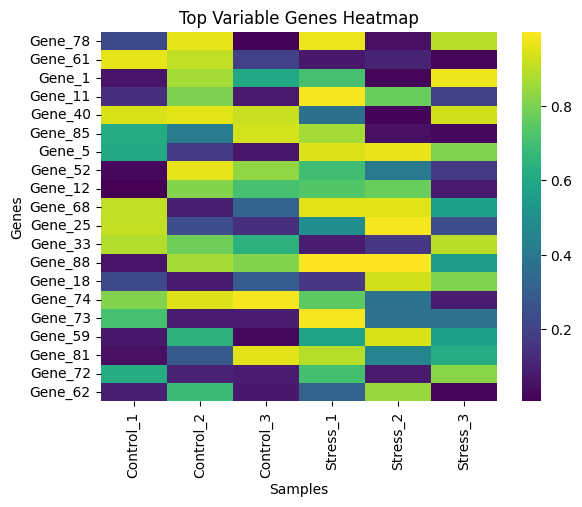

In [ ]:
# Select top 20 most variable genes
top_genes = data.var(axis=1).sort_values(ascending=False).head(20).index

heatmap_data = data.loc[top_genes]

# Plot heatmap
plt.figure()
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Top Variable Genes Heatmap')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.show()